In [1]:
import pandas as pd

print("🚀 데이터 전처리 시작...")

# 1. 데이터 로드 (새로 만든 100개가 맨 밑에 추가된 상태의 파일)
file_path = 'hardnegative_data.csv'
df = pd.read_csv(file_path)
print(f"✔️ 원본 데이터 개수: {len(df)}개")

# 2. 중복 제거 ('conversation' 텍스트가 완전히 똑같은 경우 제거)
df_dedup = df.drop_duplicates(subset=['conversation'], keep='first')
num_duplicates = len(df) - len(df_dedup)
print(f"✔️ 제거된 중복 데이터 개수: {num_duplicates}개")

# 3. 데이터 셔플링 (섞기)
# 맨 밑에 추가된 100개의 데이터가 전체에 골고루 퍼지도록 섞습니다.
df_shuffled = df_dedup.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✔️ 최종 섞인 데이터 개수: {len(df_shuffled)}개")

# 4. 학습용 최종 파일로 저장 (올려주신 학습 코드의 입력 파일명과 맞춤)
output_filename = '../Xuxeong/final_train_data.csv' # 경로 확인 필요
df_shuffled.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ 전처리 완료! '{output_filename}' 파일로 덮어쓰기 되었습니다.")

🚀 데이터 전처리 시작...
✔️ 원본 데이터 개수: 5135개
✔️ 제거된 중복 데이터 개수: 1개
✔️ 최종 섞인 데이터 개수: 5134개
✅ 전처리 완료! '../Xuxeong/final_train_data.csv' 파일로 덮어쓰기 되었습니다.


In [2]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)

# ---------------------------------------------
# 0. 메모리 초기화
# ---------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ---------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------
train_combined_path = '../Xuxeong/final_train_data.csv'
df = pd.read_csv(train_combined_path)
df = df.dropna(subset=['conversation', 'label'])

# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---------------------------------------------
# 2. 모델 및 토크나이저 로드 (하이퍼파라미터 원본 유지)
# ---------------------------------------------
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 5          
LEARNING_RATE = 1e-5

MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# ---------------------------------------------
# 3. Custom Dataset 클래스
# ---------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = KcElectraDataset(train_df['conversation'].values, train_df['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

# ---------------------------------------------
# 4. 평가지표 계산 함수
# ---------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# ---------------------------------------------
# 5. Trainer 셋팅 및 학습 (Training)
# ---------------------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,                    # EPOCHS = 5
    per_device_train_batch_size=32,        # BATCH_SIZE = 32
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                    # LEARNING_RATE = 1e-5
    weight_decay=0.01,                     # Weight Decay = 0.01
    adam_epsilon=1e-5,                     # Epsilon = 1e-5
    max_grad_norm=1.0,                     # Max Grad Norm = 1.0
    warmup_ratio=0.1,                      # SCHEDULER = 10% Warmup
    lr_scheduler_type="linear",            # SCHEDULER = Linear
    seed=42,                               # SEED = 42
    eval_strategy="epoch",                 # (에러 수정됨) 에포크마다 평가
    save_strategy="epoch",                 
    logging_steps=50,                      
    report_to="none"                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("▶ [1/2] 모델 학습을 시작합니다...\n")
trainer.train()

# ==========================================
# 6. 최종 평가 및 리포트 출력 (Evaluation)
# ==========================================
print("\n▶ [2/2] 최종 모델 성능 평가를 진행합니다...")

# 기본 metrics 확인 (eval_loss, eval_accuracy 등)
eval_results = trainer.evaluate()

print("-" * 50)
print("🎯 [최종 검증 세트(Validation Set) 평가 결과]")
print(f" - Loss (손실): {eval_results['eval_loss']:.4f}")
print(f" - Accuracy (정확도): {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print("-" * 50)

print("\n▶ 검증 데이터셋 상세 예측 중...")
# val_dataset에 대해 예측을 수행하여 로짓(logits) 추출
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# 타겟 이름 맵핑 (0~4번 인덱스 순서에 맞게 설정)
target_names = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

print("\n" + "="*60)
print("🎯 [KcELECTRA 상세 성능 리포트]")
print("="*60)
# 실제 정답(val_df['label'])과 모델의 예측값(preds) 비교
print(classification_report(val_df['label'].values, preds, target_names=target_names, zero_division=0))
print("="*60)

# 학습된 모델 및 토크나이저 안전하게 저장
save_directory = "./best_kcelectra_model2"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\n✅ 학습 완료! 모델과 토크나이저가 '{save_directory}' 폴더에 안전하게 저장되었습니다.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

▶ [1/2] 모델 학습을 시작합니다...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.357316,0.955833,0.784810,0.765201
2,0.591878,0.430589,0.911392,0.904223
3,0.391494,0.304509,0.918208,0.912115
4,0.298413,0.264761,0.926972,0.921738
5,0.242866,0.249102,0.928919,0.923835


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.242866,0.249102,5,0.928919,0.923835


--------------------------------------------------
🎯 [최종 검증 세트(Validation Set) 평가 결과]
 - Loss (손실): 0.2491
 - Accuracy (정확도): 92.89%
 - F1 Score (Macro): 0.9238
--------------------------------------------------

▶ 검증 데이터셋 상세 예측 중...



🎯 [KcELECTRA 상세 성능 리포트]
              precision    recall  f1-score   support

       협박 대화       0.88      0.88      0.88       178
       갈취 대화       0.91      0.91      0.91       195
 직장 내 괴롭힘 대화       0.93      0.96      0.94       194
   기타 괴롭힘 대화       0.93      0.87      0.90       202
       일반 대화       0.98      1.00      0.99       258

    accuracy                           0.93      1027
   macro avg       0.92      0.92      0.92      1027
weighted avg       0.93      0.93      0.93      1027



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 학습 완료! 모델과 토크나이저가 './best_kcelectra_model2' 폴더에 안전하게 저장되었습니다.


In [3]:
print(df['label'].value_counts().sort_index())

label
0     892
1     973
2     970
3    1010
4    1289
Name: count, dtype: int64


In [4]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 데이터 로드 (경로 확인 필수)
test_df = pd.read_csv('./data/test.csv') 

# 디바이스 설정 추가 (GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] # test.csv의 컬럼명에 맞춤
    text = str(row['conversation'])
    
    # 학습 시 전처리 함수가 선언되어 있다면 자동 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 숫자로 된 클래스 번호(0, 1, 2, 3, 4)를 추출
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission.csv 저장
submission_df = pd.DataFrame(submission_list)
submission_df.to_csv('submission.csv', index=False)

print("\n✅ submission.csv 생성 완료!")
print(submission_df.head())

🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...


100%|██████████| 500/500 [00:05<00:00, 93.26it/s]


✅ submission.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       3


In [5]:
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import classification_report

print("🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...")

# 💡 [수정됨] tokenized_val -> val_dataset 으로 변경
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
true_labels = predictions.label_ids

# 2. Logit을 Softmax로 변환하여 확률(확신도) 계산
probs = softmax(logits, axis=1)
pred_labels = np.argmax(probs, axis=1)         # 가장 높은 확률의 라벨(0~4)
confidences = np.max(probs, axis=1) * 100      # 가장 높은 확률의 퍼센트(%)

# 3. 기본 성적표 출력
target_names = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']
print("\n" + "="*50)
print("📊 [클래스별 상세 성적표]")
print("="*50)
print(classification_report(true_labels, pred_labels, target_names=target_names))

# =====================================================================
# 🌟 모델의 확신도를 바탕으로 한 '오답 노트' 생성
# =====================================================================

# 원본 텍스트를 가져와서 데이터프레임으로 묶기 (val_df 사용)
error_analysis_df = pd.DataFrame({
    '문장': val_df['conversation'].values,
    '정답': [target_names[i] for i in true_labels],
    '예측': [target_names[i] for i in pred_labels],
    '확신도(%)': np.round(confidences, 2)
})

# 4-1. 모델이 틀린 문제만 필터링
wrong_preds = error_analysis_df[error_analysis_df['정답'] != error_analysis_df['예측']]

# 4-2. 확신도가 높은 순서대로 정렬 (완전 확신했는데 틀린 '최악의 오답')
worst_mistakes = wrong_preds.sort_values(by='확신도(%)', ascending=False)

print("\n" + "="*80)
print("🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장")
print("="*80)

# 문장이 길어도 잘리지 않고 다 보이게 설정
pd.set_option('display.max_colwidth', None)
print(worst_mistakes.head(5).to_string(index=False))
pd.reset_option('display.max_colwidth')

# 전체 오답 노트를 CSV 파일로 저장
worst_mistakes.to_csv("model_worst_mistakes_hardnegative.csv", index=False, encoding='utf-8-sig')
print("\n✅ 새로운 오답 노트가 'model_worst_mistakes_hardnegative.csv'로 저장되었습니다.")

🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...



📊 [클래스별 상세 성적표]
              precision    recall  f1-score   support

       협박(0)       0.88      0.88      0.88       178
       갈취(1)       0.91      0.91      0.91       195
   직장내괴롭힘(2)       0.93      0.96      0.94       194
    기타괴롭힘(3)       0.93      0.87      0.90       202
     일반대화(4)       0.98      1.00      0.99       258

    accuracy                           0.93      1027
   macro avg       0.92      0.92      0.92      1027
weighted avg       0.93      0.93      0.93      1027


🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장
                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1289
- Test 일반 대화 (모델 예측) 수: 43

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.8276

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 위치가 (중요도: 0.0270)
- 원래 (중요도: 0.0157)
- 화가 (중요도: 0.0152)
- 너무 (중요도: 0.0140)
- 그래 (중요도: 0.0139)
- 그니까 (중요도: 0.0121)
- 저기 (중요도: 0.0110)
- 알겠습니다 (중요도: 0.0105)
- 여기서 (중요도: 0.0105)
- 조심히 (중요도: 0.0101)
- 오늘도 (중요도: 0.0097)
- 에버랜드 (중요도: 0.0097)
- 죽겠어 (중요도: 0.0092)
- 채우는 (중요도: 0.0086)
- 보자마자 (중요도: 0.0079)


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52712 (\N{HANGUL SYLLABLE CWI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from f

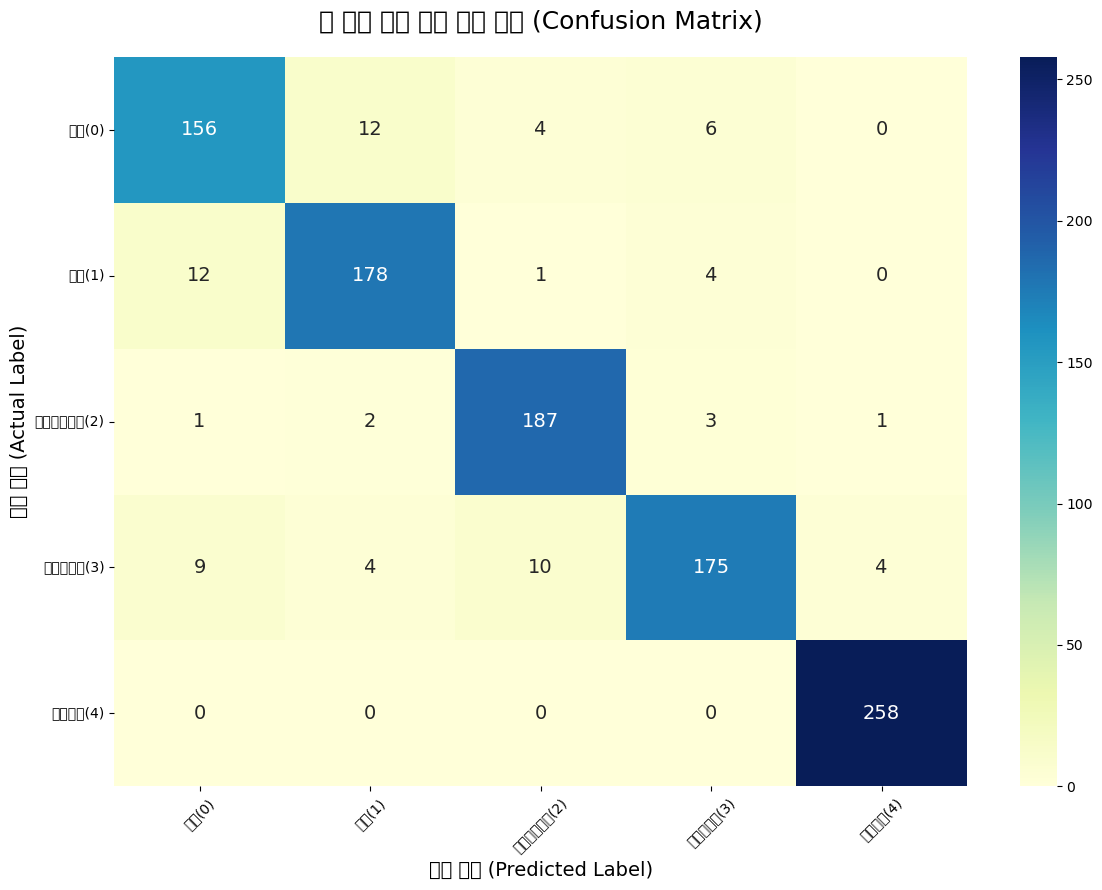

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.font_manager as fm

# 1. 한글 폰트 설정 (환경에 따라 선택)
# 코랩의 경우 아래 코드로 나눔바른고딕 설치 및 설정이 필요할 수 있습니다.
plt.rc('font', family='NanumBarunGothic') 

def plot_enhanced_confusion_matrix(y_true, y_pred, labels):
    # 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 9))
    
    # 히트맵 그리기
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 14}) # 숫자 크기 조절
    
    plt.title('🚨 위험 대화 분류 혼동 행렬 (Confusion Matrix)', fontsize=18, pad=20)
    plt.ylabel('실제 정답 (Actual Label)', fontsize=14)
    plt.xlabel('모델 예측 (Predicted Label)', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 2. 실행 (제공해주신 변수명: true_labels, pred_labels 사용)
target_names_with_normal = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']

plot_enhanced_confusion_matrix(true_labels, pred_labels, target_names_with_normal)


In [11]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 3][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 3][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1010
- Test 일반 대화 (모델 예측) 수: 125

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.4678

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 뭐하냐 (중요도: 0.0089)
- 갈래 (중요도: 0.0079)
- 있구나 (중요도: 0.0071)
- 친구가 (중요도: 0.0065)
- 일단 (중요도: 0.0062)
- 아빠가 (중요도: 0.0060)
- 엄마한테 (중요도: 0.0058)
- 그렇지 (중요도: 0.0058)
- 니가뭔데 (중요도: 0.0057)
- 그니까 (중요도: 0.0056)
- 졸라 (중요도: 0.0055)
- 간다 (중요도: 0.0053)
- 맞다 (중요도: 0.0053)
- 고마워 (중요도: 0.0052)
- 손이 (중요도: 0.0051)


In [12]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 2][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 2][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 970
- Test 일반 대화 (모델 예측) 수: 121

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.5946

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 기분이 (중요도: 0.0087)
- 저녁 (중요도: 0.0083)
- 아침 (중요도: 0.0058)
- 대리님 (중요도: 0.0056)
- 오늘 (중요도: 0.0053)
- 그냥 (중요도: 0.0052)
- 무슨 (중요도: 0.0050)
- 그러면 (중요도: 0.0048)
- 똑바로 (중요도: 0.0045)
- 약속 (중요도: 0.0044)
- 내가 (중요도: 0.0044)
- 지켜볼거야 (중요도: 0.0044)
- 주말에 (중요도: 0.0044)
- 얼마나 (중요도: 0.0043)
- 당신이 (중요도: 0.0042)


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 1][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 1][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 973
- Test 일반 대화 (모델 예측) 수: 112

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.4015

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 저요 (중요도: 0.0101)
- 줄거야 (중요도: 0.0064)
- 돈내놔 (중요도: 0.0062)
- 별로 (중요도: 0.0057)
- 우리 (중요도: 0.0054)
- 아무리 (중요도: 0.0054)
- 어디서 (중요도: 0.0052)
- 있으면 (중요도: 0.0050)
- 마지막으로 (중요도: 0.0050)
- 부족한데 (중요도: 0.0049)
- 딱봐도 (중요도: 0.0045)
- 줘봐 (중요도: 0.0045)
- 알지 (중요도: 0.0043)
- 없는데요 (중요도: 0.0042)
- 들어가 (중요도: 0.0042)


In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 0][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 0][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 892
- Test 일반 대화 (모델 예측) 수: 99

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.5356

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 죽고 (중요도: 0.0065)
- 내려 (중요도: 0.0064)
- 맞고 (중요도: 0.0063)
- 할게 (중요도: 0.0056)
- 나갈게 (중요도: 0.0051)
- 달라고 (중요도: 0.0050)
- 먼저 (중요도: 0.0050)
- 있습니다 (중요도: 0.0049)
- 그럼 (중요도: 0.0047)
- 있다고요 (중요도: 0.0047)
- 차에서 (중요도: 0.0046)
- 타고 (중요도: 0.0045)
- 제발 (중요도: 0.0045)
- 해라 (중요도: 0.0045)
- 그거는 (중요도: 0.0043)


In [15]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission_5fold_ensemble.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1289
- Test 일반 대화 (모델 예측) 수: 27

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.6062

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 알겠습니다 (중요도: 0.0319)
- 사람이 (중요도: 0.0191)
- 있고 (중요도: 0.0176)
- 그런 (중요도: 0.0155)
- 그러면 (중요도: 0.0145)
- 저기 (중요도: 0.0139)
- 위해 (중요도: 0.0130)
- 기분이 (중요도: 0.0125)
- 지금 (중요도: 0.0124)
- 보냈어 (중요도: 0.0122)
- 화가 (중요도: 0.0122)
- 땡기는데 (중요도: 0.0114)
- 있나 (중요도: 0.0113)
- 잘했다 (중요도: 0.0109)
- 가까운 (중요도: 0.0107)


In [16]:
import pandas as pd

print("🚀 데이터 전처리 시작...")

# 1. 데이터 로드 (새로 만든 100개가 맨 밑에 추가된 상태의 파일)
file_path = 'hardnegative_data_v2.csv'
df = pd.read_csv(file_path)
print(f"✔️ 원본 데이터 개수: {len(df)}개")

# 2. 중복 제거 ('conversation' 텍스트가 완전히 똑같은 경우 제거)
df_dedup = df.drop_duplicates(subset=['conversation'], keep='first')
num_duplicates = len(df) - len(df_dedup)
print(f"✔️ 제거된 중복 데이터 개수: {num_duplicates}개")

# 3. 데이터 셔플링 (섞기)
# 맨 밑에 추가된 100개의 데이터가 전체에 골고루 퍼지도록 섞습니다.
df_shuffled = df_dedup.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✔️ 최종 섞인 데이터 개수: {len(df_shuffled)}개")

# 4. 학습용 최종 파일로 저장 (올려주신 학습 코드의 입력 파일명과 맞춤)
output_filename = '../Xuxeong/final_train_data2.csv' # 경로 확인 필요
df_shuffled.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ 전처리 완료! '{output_filename}' 파일로 덮어쓰기 되었습니다.")

🚀 데이터 전처리 시작...
✔️ 원본 데이터 개수: 5185개
✔️ 제거된 중복 데이터 개수: 1개
✔️ 최종 섞인 데이터 개수: 5184개
✅ 전처리 완료! '../Xuxeong/final_train_data2.csv' 파일로 덮어쓰기 되었습니다.


In [18]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)

# ---------------------------------------------
# 0. 메모리 초기화
# ---------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ---------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------
train_combined_path = '../Xuxeong/final_train_data2.csv'
df = pd.read_csv(train_combined_path)
df = df.dropna(subset=['conversation', 'label'])

# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---------------------------------------------
# 2. 모델 및 토크나이저 로드 (하이퍼파라미터 원본 유지)
# ---------------------------------------------
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 5          
LEARNING_RATE = 1e-5

MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# ---------------------------------------------
# 3. Custom Dataset 클래스
# ---------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = KcElectraDataset(train_df['conversation'].values, train_df['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

# ---------------------------------------------
# 4. 평가지표 계산 함수
# ---------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# ---------------------------------------------
# 5. Trainer 셋팅 및 학습 (Training)
# ---------------------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,                    # EPOCHS = 5
    per_device_train_batch_size=32,        # BATCH_SIZE = 32
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                    # LEARNING_RATE = 1e-5
    weight_decay=0.01,                     # Weight Decay = 0.01
    adam_epsilon=1e-5,                     # Epsilon = 1e-5
    max_grad_norm=1.0,                     # Max Grad Norm = 1.0
    warmup_ratio=0.1,                      # SCHEDULER = 10% Warmup
    lr_scheduler_type="linear",            # SCHEDULER = Linear
    seed=42,                               # SEED = 42
    eval_strategy="epoch",                 # (에러 수정됨) 에포크마다 평가
    save_strategy="epoch",                 
    logging_steps=50,                      
    report_to="none"                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("▶ [1/2] 모델 학습을 시작합니다...\n")
trainer.train()

# ==========================================
# 6. 최종 평가 및 리포트 출력 (Evaluation)
# ==========================================
print("\n▶ [2/2] 최종 모델 성능 평가를 진행합니다...")

# 기본 metrics 확인 (eval_loss, eval_accuracy 등)
eval_results = trainer.evaluate()

print("-" * 50)
print("🎯 [최종 검증 세트(Validation Set) 평가 결과]")
print(f" - Loss (손실): {eval_results['eval_loss']:.4f}")
print(f" - Accuracy (정확도): {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print("-" * 50)

print("\n▶ 검증 데이터셋 상세 예측 중...")
# val_dataset에 대해 예측을 수행하여 로짓(logits) 추출
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# 타겟 이름 맵핑 (0~4번 인덱스 순서에 맞게 설정)
target_names = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

print("\n" + "="*60)
print("🎯 [KcELECTRA 상세 성능 리포트]")
print("="*60)
# 실제 정답(val_df['label'])과 모델의 예측값(preds) 비교
print(classification_report(val_df['label'].values, preds, target_names=target_names, zero_division=0))
print("="*60)

# 학습된 모델 및 토크나이저 안전하게 저장
save_directory = "./best_kcelectra_model3"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\n✅ 학습 완료! 모델과 토크나이저가 '{save_directory}' 폴더에 안전하게 저장되었습니다.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

▶ [1/2] 모델 학습을 시작합니다...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.370545,0.947347,0.789778,0.765064
2,0.571178,0.429468,0.901639,0.893014
3,0.387496,0.323505,0.908390,0.900885
4,0.274013,0.295712,0.906461,0.898986
5,0.239751,0.286336,0.909354,0.902050


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.239751,0.286336,5,0.909354,0.902050


--------------------------------------------------
🎯 [최종 검증 세트(Validation Set) 평가 결과]
 - Loss (손실): 0.2863
 - Accuracy (정확도): 90.94%
 - F1 Score (Macro): 0.9020
--------------------------------------------------

▶ 검증 데이터셋 상세 예측 중...



🎯 [KcELECTRA 상세 성능 리포트]
              precision    recall  f1-score   support

       협박 대화       0.88      0.81      0.84       178
       갈취 대화       0.85      0.90      0.88       195
 직장 내 괴롭힘 대화       0.93      0.94      0.94       194
   기타 괴롭힘 대화       0.86      0.87      0.86       202
       일반 대화       0.99      0.99      0.99       268

    accuracy                           0.91      1037
   macro avg       0.90      0.90      0.90      1037
weighted avg       0.91      0.91      0.91      1037



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 학습 완료! 모델과 토크나이저가 './best_kcelectra_model3' 폴더에 안전하게 저장되었습니다.


In [19]:
print(df['label'].value_counts().sort_index())

label
0     892
1     973
2     970
3    1010
4    1339
Name: count, dtype: int64


In [20]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 데이터 로드 (경로 확인 필수)
test_df = pd.read_csv('./data/test.csv') 

# 디바이스 설정 추가 (GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] # test.csv의 컬럼명에 맞춤
    text = str(row['conversation'])
    
    # 학습 시 전처리 함수가 선언되어 있다면 자동 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 숫자로 된 클래스 번호(0, 1, 2, 3, 4)를 추출
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission.csv 저장
submission_df = pd.DataFrame(submission_list)
submission_df.to_csv('submission.csv', index=False)

print("\n✅ submission.csv 생성 완료!")
print(submission_df.head())

🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...


100%|██████████| 500/500 [00:05<00:00, 89.19it/s]


✅ submission.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       3


In [21]:
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import classification_report

print("🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...")

# 💡 [수정됨] tokenized_val -> val_dataset 으로 변경
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
true_labels = predictions.label_ids

# 2. Logit을 Softmax로 변환하여 확률(확신도) 계산
probs = softmax(logits, axis=1)
pred_labels = np.argmax(probs, axis=1)         # 가장 높은 확률의 라벨(0~4)
confidences = np.max(probs, axis=1) * 100      # 가장 높은 확률의 퍼센트(%)

# 3. 기본 성적표 출력
target_names = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']
print("\n" + "="*50)
print("📊 [클래스별 상세 성적표]")
print("="*50)
print(classification_report(true_labels, pred_labels, target_names=target_names))

# =====================================================================
# 🌟 모델의 확신도를 바탕으로 한 '오답 노트' 생성
# =====================================================================

# 원본 텍스트를 가져와서 데이터프레임으로 묶기 (val_df 사용)
error_analysis_df = pd.DataFrame({
    '문장': val_df['conversation'].values,
    '정답': [target_names[i] for i in true_labels],
    '예측': [target_names[i] for i in pred_labels],
    '확신도(%)': np.round(confidences, 2)
})

# 4-1. 모델이 틀린 문제만 필터링
wrong_preds = error_analysis_df[error_analysis_df['정답'] != error_analysis_df['예측']]

# 4-2. 확신도가 높은 순서대로 정렬 (완전 확신했는데 틀린 '최악의 오답')
worst_mistakes = wrong_preds.sort_values(by='확신도(%)', ascending=False)

print("\n" + "="*80)
print("🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장")
print("="*80)

# 문장이 길어도 잘리지 않고 다 보이게 설정
pd.set_option('display.max_colwidth', None)
print(worst_mistakes.head(5).to_string(index=False))
pd.reset_option('display.max_colwidth')

# 전체 오답 노트를 CSV 파일로 저장
worst_mistakes.to_csv("model_worst_mistakes_hardnegative2.csv", index=False, encoding='utf-8-sig')
print("\n✅ 새로운 오답 노트가 'model_worst_mistakes_hardnegative2.csv'로 저장되었습니다.")

🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...



📊 [클래스별 상세 성적표]
              precision    recall  f1-score   support

       협박(0)       0.88      0.81      0.84       178
       갈취(1)       0.85      0.90      0.88       195
   직장내괴롭힘(2)       0.93      0.94      0.94       194
    기타괴롭힘(3)       0.86      0.87      0.86       202
     일반대화(4)       0.99      0.99      0.99       268

    accuracy                           0.91      1037
   macro avg       0.90      0.90      0.90      1037
weighted avg       0.91      0.91      0.91      1037


🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장
                                                                                                                                                                                                                                                                                                                                                                                           문장       정답        예측    확신도(%)
                                        

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data2.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1339
- Test 일반 대화 (모델 예측) 수: 52

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.7358

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 안경 (중요도: 0.0180)
- 기타 (중요도: 0.0154)
- 원래 (중요도: 0.0138)
- 위해 (중요도: 0.0129)
- 나를 (중요도: 0.0093)
- 그치 (중요도: 0.0092)
- 사람이 (중요도: 0.0090)
- 위치가 (중요도: 0.0090)
- 알았어 (중요도: 0.0087)
- 오늘 (중요도: 0.0083)
- 운동도 (중요도: 0.0078)
- 알아서 (중요도: 0.0076)
- 그런 (중요도: 0.0076)
- 기분이 (중요도: 0.0075)
- 시간을 (중요도: 0.0073)


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52712 (\N{HANGUL SYLLABLE CWI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from f

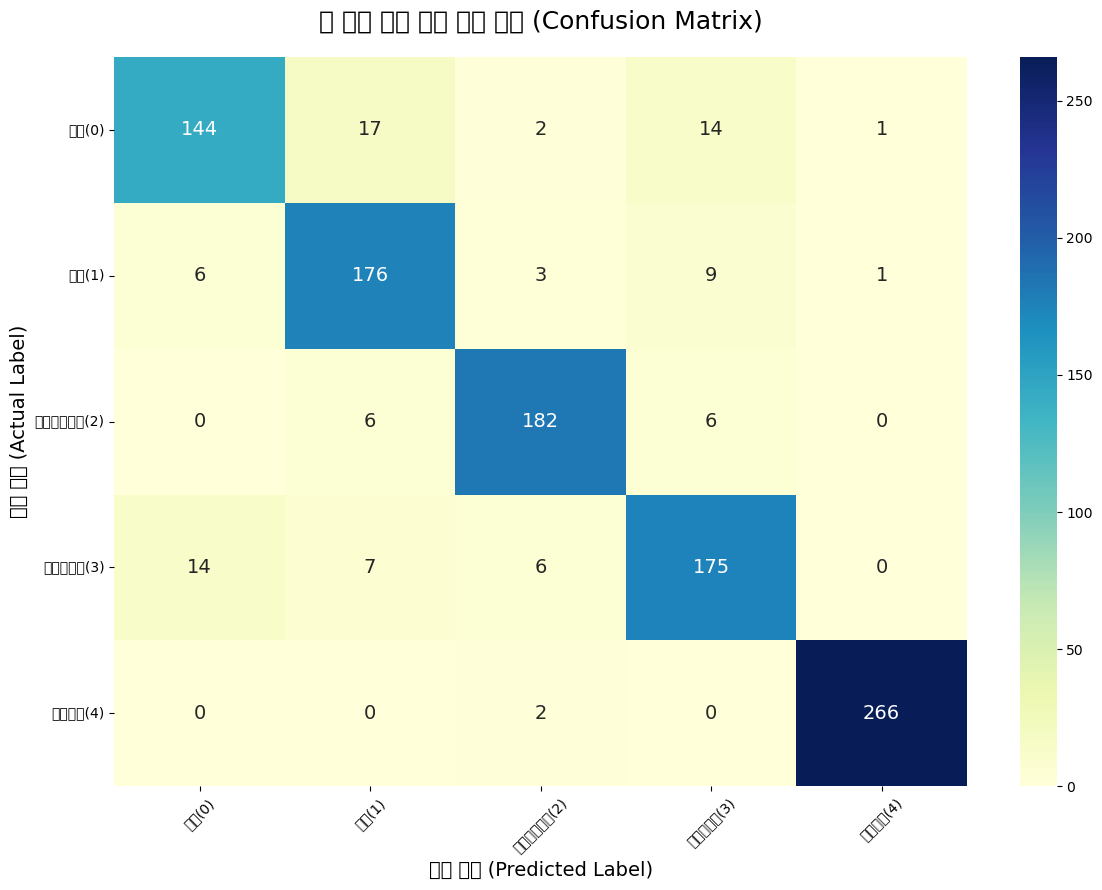

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.font_manager as fm

# 1. 한글 폰트 설정 (환경에 따라 선택)
# 코랩의 경우 아래 코드로 나눔바른고딕 설치 및 설정이 필요할 수 있습니다.
plt.rc('font', family='NanumBarunGothic') 

def plot_enhanced_confusion_matrix(y_true, y_pred, labels):
    # 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 9))
    
    # 히트맵 그리기
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 14}) # 숫자 크기 조절
    
    plt.title('🚨 위험 대화 분류 혼동 행렬 (Confusion Matrix)', fontsize=18, pad=20)
    plt.ylabel('실제 정답 (Actual Label)', fontsize=14)
    plt.xlabel('모델 예측 (Predicted Label)', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 2. 실행 (제공해주신 변수명: true_labels, pred_labels 사용)
target_names_with_normal = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']

plot_enhanced_confusion_matrix(true_labels, pred_labels, target_names_with_normal)


In [24]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data2.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission_5fold_ensemble.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1339
- Test 일반 대화 (모델 예측) 수: 27

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.8528

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 나를 (중요도: 0.0178)
- 즐겁게 (중요도: 0.0157)
- 알아서 (중요도: 0.0146)
- 가까운 (중요도: 0.0135)
- 입은 (중요도: 0.0134)
- 저기 (중요도: 0.0134)
- 보냈어 (중요도: 0.0130)
- 직장 (중요도: 0.0120)
- 오늘 (중요도: 0.0120)
- 나고 (중요도: 0.0114)
- 원래 (중요도: 0.0113)
- 있나요 (중요도: 0.0110)
- 그러면 (중요도: 0.0099)
- 사람이 (중요도: 0.0098)
- 아냐 (중요도: 0.0097)


In [1]:
import pandas as pd

print("🚀 데이터 전처리 시작...")

# 1. 데이터 로드 (새로 만든 100개가 맨 밑에 추가된 상태의 파일)
file_path = 'hardnegative_data_v3.csv'
df = pd.read_csv(file_path)
print(f"✔️ 원본 데이터 개수: {len(df)}개")

# 2. 중복 제거 ('conversation' 텍스트가 완전히 똑같은 경우 제거)
df_dedup = df.drop_duplicates(subset=['conversation'], keep='first')
num_duplicates = len(df) - len(df_dedup)
print(f"✔️ 제거된 중복 데이터 개수: {num_duplicates}개")

# 3. 데이터 셔플링 (섞기)
# 맨 밑에 추가된 100개의 데이터가 전체에 골고루 퍼지도록 섞습니다.
df_shuffled = df_dedup.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✔️ 최종 섞인 데이터 개수: {len(df_shuffled)}개")

# 4. 학습용 최종 파일로 저장 (올려주신 학습 코드의 입력 파일명과 맞춤)
output_filename = '../Xuxeong/final_train_data3.csv' # 경로 확인 필요
df_shuffled.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ 전처리 완료! '{output_filename}' 파일로 덮어쓰기 되었습니다.")

🚀 데이터 전처리 시작...
✔️ 원본 데이터 개수: 5245개
✔️ 제거된 중복 데이터 개수: 1개
✔️ 최종 섞인 데이터 개수: 5244개
✅ 전처리 완료! '../Xuxeong/final_train_data3.csv' 파일로 덮어쓰기 되었습니다.


In [5]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)

# ---------------------------------------------
# 0. 메모리 초기화
# ---------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ---------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------
train_combined_path = '../Xuxeong/final_train_data3.csv'
df = pd.read_csv(train_combined_path)
df = df.dropna(subset=['conversation', 'label'])

# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---------------------------------------------
# 2. 모델 및 토크나이저 로드 (하이퍼파라미터 원본 유지)
# ---------------------------------------------
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 5          
LEARNING_RATE = 1e-5

MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# ---------------------------------------------
# 3. Custom Dataset 클래스
# ---------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = KcElectraDataset(train_df['conversation'].values, train_df['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

# ---------------------------------------------
# 4. 평가지표 계산 함수
# ---------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# ---------------------------------------------
# 5. Trainer 셋팅 및 학습 (Training)
# ---------------------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,                    # EPOCHS = 5
    per_device_train_batch_size=32,        # BATCH_SIZE = 32
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                    # LEARNING_RATE = 1e-5
    weight_decay=0.01,                     # Weight Decay = 0.01
    adam_epsilon=1e-5,                     # Epsilon = 1e-5
    max_grad_norm=1.0,                     # Max Grad Norm = 1.0
    warmup_ratio=0.1,                      # SCHEDULER = 10% Warmup
    lr_scheduler_type="linear",            # SCHEDULER = Linear
    seed=42,                               # SEED = 42
    eval_strategy="epoch",                 # (에러 수정됨) 에포크마다 평가
    save_strategy="epoch",                 
    logging_steps=50,                      
    report_to="none"                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("▶ [1/2] 모델 학습을 시작합니다...\n")
trainer.train()

# ==========================================
# 6. 최종 평가 및 리포트 출력 (Evaluation)
# ==========================================
print("\n▶ [2/2] 최종 모델 성능 평가를 진행합니다...")

# 기본 metrics 확인 (eval_loss, eval_accuracy 등)
eval_results = trainer.evaluate()

print("-" * 50)
print("🎯 [최종 검증 세트(Validation Set) 평가 결과]")
print(f" - Loss (손실): {eval_results['eval_loss']:.4f}")
print(f" - Accuracy (정확도): {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print("-" * 50)

print("\n▶ 검증 데이터셋 상세 예측 중...")
# val_dataset에 대해 예측을 수행하여 로짓(logits) 추출
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# 타겟 이름 맵핑 (0~4번 인덱스 순서에 맞게 설정)
target_names = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

print("\n" + "="*60)
print("🎯 [KcELECTRA 상세 성능 리포트]")
print("="*60)
# 실제 정답(val_df['label'])과 모델의 예측값(preds) 비교
print(classification_report(val_df['label'].values, preds, target_names=target_names, zero_division=0))
print("="*60)

# 학습된 모델 및 토크나이저 안전하게 저장
save_directory = "./best_kcelectra_model4"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\n✅ 학습 완료! 모델과 토크나이저가 '{save_directory}' 폴더에 안전하게 저장되었습니다.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

▶ [1/2] 모델 학습을 시작합니다...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.356928,0.951109,0.776930,0.743807
2,0.603509,0.458668,0.898951,0.890637
3,0.377632,0.325357,0.910391,0.901674
4,0.288923,0.293122,0.917064,0.909756
5,0.220513,0.278717,0.919924,0.912906


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.220513,0.278717,5,0.919924,0.912906


--------------------------------------------------
🎯 [최종 검증 세트(Validation Set) 평가 결과]
 - Loss (손실): 0.2787
 - Accuracy (정확도): 91.99%
 - F1 Score (Macro): 0.9129
--------------------------------------------------

▶ 검증 데이터셋 상세 예측 중...



🎯 [KcELECTRA 상세 성능 리포트]
              precision    recall  f1-score   support

       협박 대화       0.89      0.87      0.88       178
       갈취 대화       0.85      0.90      0.87       195
 직장 내 괴롭힘 대화       0.96      0.94      0.95       194
   기타 괴롭힘 대화       0.88      0.85      0.87       202
       일반 대화       0.99      1.00      1.00       280

    accuracy                           0.92      1049
   macro avg       0.91      0.91      0.91      1049
weighted avg       0.92      0.92      0.92      1049



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 학습 완료! 모델과 토크나이저가 './best_kcelectra_model4' 폴더에 안전하게 저장되었습니다.


In [6]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 데이터 로드 (경로 확인 필수)
test_df = pd.read_csv('./data/test.csv') 

# 디바이스 설정 추가 (GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] # test.csv의 컬럼명에 맞춤
    text = str(row['conversation'])
    
    # 학습 시 전처리 함수가 선언되어 있다면 자동 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 숫자로 된 클래스 번호(0, 1, 2, 3, 4)를 추출
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission.csv 저장
submission_df = pd.DataFrame(submission_list)
submission_df.to_csv('submission.csv', index=False)

print("\n✅ submission.csv 생성 완료!")
print(submission_df.head())

🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...


100%|██████████| 500/500 [00:05<00:00, 88.84it/s]


✅ submission.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       3


In [7]:
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import classification_report

print("🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...")

# 💡 [수정됨] tokenized_val -> val_dataset 으로 변경
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
true_labels = predictions.label_ids

# 2. Logit을 Softmax로 변환하여 확률(확신도) 계산
probs = softmax(logits, axis=1)
pred_labels = np.argmax(probs, axis=1)         # 가장 높은 확률의 라벨(0~4)
confidences = np.max(probs, axis=1) * 100      # 가장 높은 확률의 퍼센트(%)

# 3. 기본 성적표 출력
target_names = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']
print("\n" + "="*50)
print("📊 [클래스별 상세 성적표]")
print("="*50)
print(classification_report(true_labels, pred_labels, target_names=target_names))

# =====================================================================
# 🌟 모델의 확신도를 바탕으로 한 '오답 노트' 생성
# =====================================================================

# 원본 텍스트를 가져와서 데이터프레임으로 묶기 (val_df 사용)
error_analysis_df = pd.DataFrame({
    '문장': val_df['conversation'].values,
    '정답': [target_names[i] for i in true_labels],
    '예측': [target_names[i] for i in pred_labels],
    '확신도(%)': np.round(confidences, 2)
})

# 4-1. 모델이 틀린 문제만 필터링
wrong_preds = error_analysis_df[error_analysis_df['정답'] != error_analysis_df['예측']]

# 4-2. 확신도가 높은 순서대로 정렬 (완전 확신했는데 틀린 '최악의 오답')
worst_mistakes = wrong_preds.sort_values(by='확신도(%)', ascending=False)

print("\n" + "="*80)
print("🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장")
print("="*80)

# 문장이 길어도 잘리지 않고 다 보이게 설정
pd.set_option('display.max_colwidth', None)
print(worst_mistakes.head(5).to_string(index=False))
pd.reset_option('display.max_colwidth')

# 전체 오답 노트를 CSV 파일로 저장
worst_mistakes.to_csv("model_worst_mistakes_hardnegative3.csv", index=False, encoding='utf-8-sig')
print("\n✅ 새로운 오답 노트가 'model_worst_mistakes_hardnegative3.csv'로 저장되었습니다.")

🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...



📊 [클래스별 상세 성적표]
              precision    recall  f1-score   support

       협박(0)       0.89      0.87      0.88       178
       갈취(1)       0.85      0.90      0.87       195
   직장내괴롭힘(2)       0.96      0.94      0.95       194
    기타괴롭힘(3)       0.88      0.85      0.87       202
     일반대화(4)       0.99      1.00      1.00       280

    accuracy                           0.92      1049
   macro avg       0.91      0.91      0.91      1049
weighted avg       0.92      0.92      0.92      1049


🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장
                                                                                                                                                                                                                                                                                                               문장        정답        예측    확신도(%)
                                                          이게 뭐야 ? 아 나 요즘 취미로 하는 뜨개질이야. 갑자기 뜨개질? 응 하다보니 마음도 좀 차분해지고 

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data3.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1399
- Test 일반 대화 (모델 예측) 수: 45

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.7920

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 그래그래 (중요도: 0.0181)
- 알았어 (중요도: 0.0123)
- 원래 (중요도: 0.0120)
- 저녁은 (중요도: 0.0107)
- 사람이 (중요도: 0.0094)
- 자기가 (중요도: 0.0094)
- 있나요 (중요도: 0.0087)
- 그런 (중요도: 0.0083)
- 지금 (중요도: 0.0079)
- 오늘 (중요도: 0.0079)
- 아니 (중요도: 0.0078)
- 들어와 (중요도: 0.0076)
- 위치가 (중요도: 0.0076)
- 써서 (중요도: 0.0075)
- 하지 (중요도: 0.0073)


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52712 (\N{HANGUL SYLLABLE CWI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from f

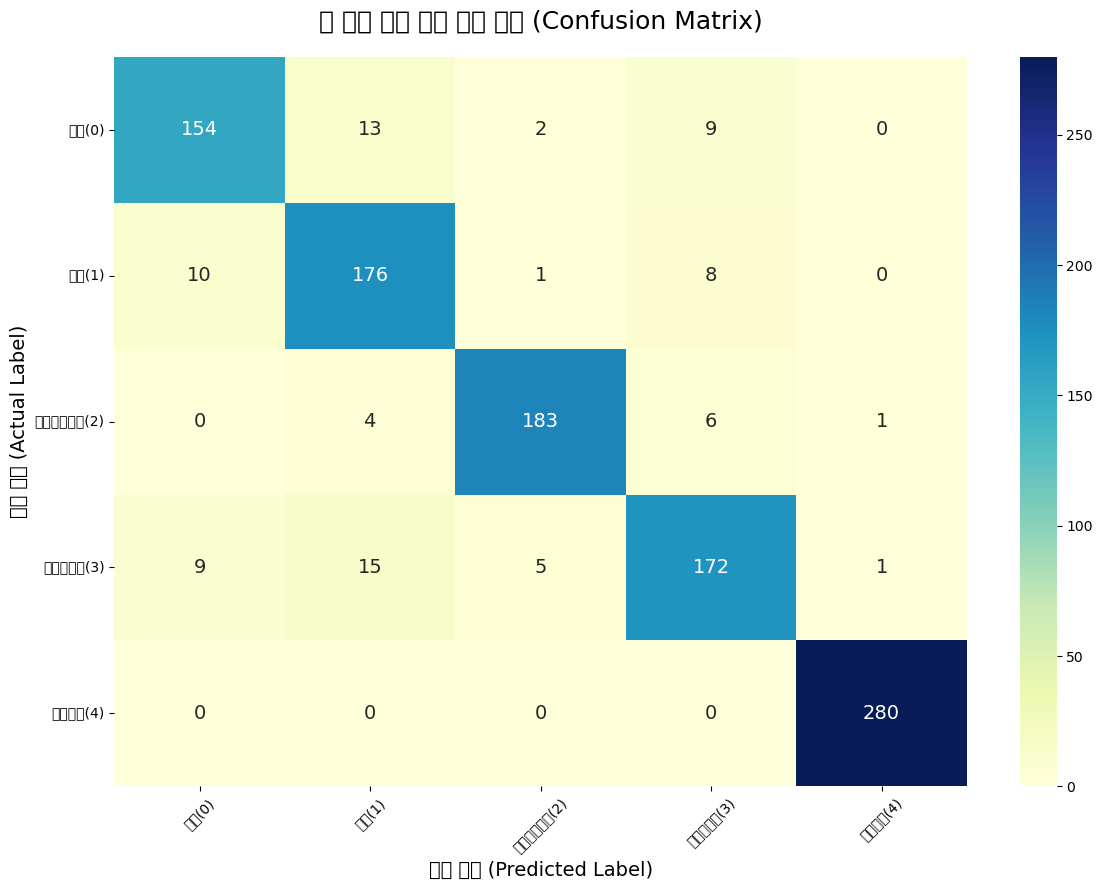

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.font_manager as fm

# 1. 한글 폰트 설정 (환경에 따라 선택)
# 코랩의 경우 아래 코드로 나눔바른고딕 설치 및 설정이 필요할 수 있습니다.
plt.rc('font', family='NanumBarunGothic') 

def plot_enhanced_confusion_matrix(y_true, y_pred, labels):
    # 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 9))
    
    # 히트맵 그리기
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 14}) # 숫자 크기 조절
    
    plt.title('🚨 위험 대화 분류 혼동 행렬 (Confusion Matrix)', fontsize=18, pad=20)
    plt.ylabel('실제 정답 (Actual Label)', fontsize=14)
    plt.xlabel('모델 예측 (Predicted Label)', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 2. 실행 (제공해주신 변수명: true_labels, pred_labels 사용)
target_names_with_normal = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']

plot_enhanced_confusion_matrix(true_labels, pred_labels, target_names_with_normal)


In [10]:
print(df['label'].value_counts().sort_index())

label
0     892
1     973
2     970
3    1010
4    1399
Name: count, dtype: int64


In [11]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...")

# 1. 🌟 원본 Train, Test 데이터 로드 (학습에 쓴 파일명과 동일하게 수정)
df_train_all = pd.read_csv('../Xuxeong/final_train_data3.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 [코드 2]에서 만든 submission.csv 로드 (파일명 수정)
try:
    df_sub = pd.read_csv('submission_5fold_ensemble.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission.csv' 파일을 찾을 수 없습니다. 추론 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(예측 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (모델 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 예측 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1399
- Test 일반 대화 (모델 예측) 수: 27

📊 Train(합성 일반) vs Test(예측 일반) AUC: 0.6558

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 그런 (중요도: 0.0180)
- 사람이 (중요도: 0.0166)
- 보냈어 (중요도: 0.0162)
- 곳이야 (중요도: 0.0149)
- 그러면 (중요도: 0.0146)
- 좋겠어요 (중요도: 0.0142)
- 오늘 (중요도: 0.0132)
- 있나요 (중요도: 0.0120)
- 아니 (중요도: 0.0120)
- 계속 (중요도: 0.0118)
- 지금 (중요도: 0.0117)
- 문제가 (중요도: 0.0116)
- 남았어 (중요도: 0.0112)
- 자기가 (중요도: 0.0105)
- 원래 (중요도: 0.0104)
